In [24]:
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import numpy as np

In this Guide we will look at a method that implements importance sampling so that we spend most of the time in regions where the probability is non-zero. Such Monte Carlo simulations are used in many areas of science, from studying the statistics of detectors in high-energy physics, to calculating the properties of materials in condensed matter, to studying information content in data science.

If we could generate an ensemble of $N_\alpha$ states $\{x_\alpha\}$ whose frequency of occurrence matched $P(x_\alpha) = P(E(x_\alpha))$ from the Boltzmann distribution. How do we sample an ensemble that satisfies the Boltzmann distribution?
There are several algorithms that generate an ensemble of states that satisfies the Boltzmann distribution. The most widely used is the **Metropolis-Hastings algorithm**.


**Ahilan Notes:** Markov Chains are when you have a state, and your future states depend on your previous states. 
Questions to ask Prof: Would an update formula be essentially what a Markov Chain be? I think I heard this in Linear Algebra. Examples a ball kicked down slope



For example, consider a particle getting kicked around randomly on a bumpy landscape. When it is on top of a hill it has a similar chance of going left or right, but when it is on a slope it is more likely to go down than up. So how it moves depends on where it is located. In mathematics, a state/history-dependent stochastic process is known as a Markov process, and the sequence of randomly generated states is known as a Markov chain.

In Thermal Physics, the particles on a large scale eventually representing a Boltzmann Distribution is an ensemble that has a Markov Process/Chain.

The Metropolis-Hastings algorithm is as follows:
1. Start with some initial state configuration $x$, with energy $E(x)$
2. Make a move that changes the configuration to $x'$, with energy $E(x')$
3. Accept the move with probability:

$$P = \begin{cases} 1, & \Delta E = E(x') - E(x) \leq 0 \\ e^{-\beta \Delta E}, & \Delta E = E(x') - E(x) > 0 \end{cases}$$

- Moves that lower energy are always accepted and moves that raise energy are rejected or accepted based on the Boltzmann weight.
4. If the move is rejected, set the state back to $x$. Otherwise the new state is $x'$.
5. Repeat steps 2-4 until equilibrium is achieved and you sample enough states to compute the desired averages.



Professor's Notes: 
Algorithm:
- Initialize $\vec{x}_0$; specify temperature $T$.
- Calculate initial energy $E(\vec{x}_0)$
- do $i = 1, \ldots, N_{\text{iter}}$ (for $N_{\text{iter}}$ iterations of the algorithm):
  - do $j = 1, \ldots, N$ (for $N$ degrees of freedom, i.e., sweeping through all degrees of freedom):
    - Propose a random move of $\vec{x} \to \vec{x}_p$
    - Calculate $E(\vec{x}_p)$
    - If $E(\vec{x}_p) \leq E(\vec{x}_0)$ OR $\text{random()} < e^{-[E(\vec{x}_p) - E(\vec{x}_0)] / k_B T}$: accept move $\vec{x}_0 \to \vec{x}_p$; $E_0 \to E_p$
    - Else: reject move


**Ahilan's Notes:** In a way, I think of conservative minimization laws as a Metropolis-Hastings Algorithm, 
I mean think about this. Nature according to what Lagrange shows, has always acted in a way that minimises the "Action"! This is what made Lagrangian Mechanics we learnt in second year so useful! Even in my optics course, we understood that according to Fraunhofer or Fresnel, when they examined the optical path light takes, they too did a minimization pattern. 
- I am getting a Perturbation theory feel here.

Magnetization: 

The sign of $J$ depends on the type of material. For ferromagnets, $J > 0$ and favours the spins being aligned (hence magnetized) whereas $J < 0$ favours the spins being anti-aligned, leading to anti-ferromagnetic behaviour (shown on the right above). We will consider only the case of a ferromagnet where $J > 0$.

The Ising model makes the further restriction that only the nearest-neighbour spins interact, so the total energy of a particular configuration of spins on the lattice is

$$E = -\frac{J}{2} \sum_i \sum_{j \in \text{n.n.}} S_i S_j$$

For a square lattice, there are 4 nearest neighbours per site. The factor of $\frac{1}{2}$ accounts for double counting each interaction over the two sums. This energy is used in the Metropolis-Hastings algorithm to determine if moves are accepted or rejected.

> Guide

Calculating observables

When the system of spins is in the particular configuration (state) $\alpha$, the net magnetization is

$$M(\alpha) = \sum_i S_i$$

Averaging over an ensemble of $N_\alpha$ states generated at a particular temperature $T$ gives the average magnetization

$$\langle M(T) \rangle = \frac{1}{N_\alpha} \sum_\alpha M(\alpha)$$

This quantity undergoes a phase transition at $T_C$, "Which looks like a decay curve but the intensity weak"

Monte Carlo simulation of Ising Model

Here we will use the Metropolis-Hastings algorithm to simulate a finite-sized Ising model on an $L \times L$ square lattice. We will use energy units where $J = 1$.

---
## Task 1:
### 1. Analysis

Energy Change $\Delta E$ for a Single Spin Flip

The total energy of the Ising model is:
$$ E = -\frac{J}{2} \sum_i \sum_{j \in \text{n.n.}} S_i S_j $$

In this model, $S_i = \pm 1$, depicting state up and down. 
As the text says, if we change a single spin, it only affects the neighbouring 4 spin components. 

When we flip a single spin $S_i \to -S_i$, only the terms involving $S_i$ change. 

The energy contribution from spin $S_i$ interacting with its neighbours is:

$$E_i = -J \, S_i \sum_{j \in \text{n.n.}} S_j$$

(The factor of $\frac{1}{2}$ is gone because we are isolating spin $i$'s contribution, counting each bond once from $i$'s perspective.)

After the flip $S_i \to -S_i$, the new contribution is:

$$E_i' = -J \, (-S_i) \sum_{j \in \text{n.n.}} S_j = +J \, S_i \sum_{j \in \text{n.n.}} S_j$$

Therefore the energy change is:

$$\Delta E = E_i' - E_i = 2 J \, S_i \sum_{j \in \text{n.n.}} S_j$$

Since each site on a square lattice has 4 nearest neighbours, the sum $\sum_{j \in \text{n.n.}} S_j$ takes values in $\{-4, -2, 0, 2, 4\}$, and so $\Delta E \in \{-8J, -4J, 0, 4J, 8J\}$.

This means we only ever need to evaluate $e^{-\beta \Delta E}$ for at most 5 distinct values — we can precompute them!

Still note sure...

### 2. Periodic Boundary Conditions — 

For site $(i, j)$ on an $L \times L$ lattice with periodic boundary conditions:

**Verification with examples** ($L=6$):


Note: Python's negative indexing naturally handles `j-1` when $j=0$ (gives index $L-1$) and `i-1` when $i=0$ (gives index $L-1$), so no explicit modulo is needed for the left and top neighbours.

In [25]:
# Let me think of a Box that spans L = 0 to 6. 
L = 6

# And an interion point in that domain such as 
i, j = 3,4

"""
left = (i, j - 1)
right = (i, (j + 1) % L)
top = (i - 1, j)
bottom = ((i + 1) % L, j)
Professors Code""" 

print(f"left = {(i, j - 1)}")

print(f"right  = {(i, (j + 1) % L)}")
print(f"top  = {(i - 1, j)}")

print(f"bottom  = {(i + 1) % L, j}")





left = (3, 3)
right  = (3, 5)
top  = (2, 4)
bottom  = (4, 4)


In [26]:
# Next a Right Edge
i, j = 3, L-1
print(f"Right edge ({i},{j}): left={i, j-1}, right={i, (j+1)%L}, top={i-1, j}, bottom={(i+1)%L, j}")

# Bottom Edge
i, j = L-1, 3
print(f"Bottom edge ({i},{j}): left={i, j-1}, right={i, (j+1)%L}, top={i-1, j}, bottom={(i+1)%L, j}")

# Top-Left Corner
i, j = 0, 0
print(f"Top-left ({i},{j}): left={i, j-1}, right={i, (j+1)%L}, top={i-1, j}, bottom={(i+1)%L, j}")

Right edge (3,5): left=(3, 4), right=(3, 0), top=(2, 5), bottom=(4, 5)
Bottom edge (5,3): left=(5, 2), right=(5, 4), top=(4, 3), bottom=(0, 3)
Top-left (0,0): left=(0, -1), right=(0, 1), top=(-1, 0), bottom=(1, 0)


- Interior site — all neighbours within bounds
- Right edge — wraps to left edge 
- Bottom edge — wraps to top edge 
- Top-left corner — Python negative indexing handles this 

Yes it works well! If it goes over, it wraps the points back into the grid.

## Task 2: Metropolis-Hastings Simulation Code

Write code to simulate the Ising model on a square lattice of size $L \times L$ at a given thermal energy $k_B T = 1/\beta$. The code should:

- **Initialization:** Initialize the $L \times L$ lattice with random $\pm 1$ spin orientations.
- **Metropolis-Hastings sweeps:** Carry out a user-specified number of sweeps, where each sweep consists of going through all $N = L^2$ sites, flipping each one, and applying the Metropolis-Hastings rule based on $\Delta E$ and $k_B T$. For each sweep, pick $N$ lattice sites at random.
- **Equilibration:** Do a user-specified number of equilibration sweeps before sampling.
- **Sampling:** After equilibration, sample spin configurations at a user-specified interval. For each sampled state, compute and store $|M| = |\sum_i S_i|$, $M^2 = (\sum_i S_i)^2$, and total energy $E$.
- **File output:** Output computed values to a file with a reasonable naming convention encoding $L$ and $k_B T$.

In [27]:
def ising_mc(L, kBT, n_eq=200, n_sample=100, sample_interval=10, rng=None, save_file=None, return_configs=False):
     # N_eq is the user input for number of sweeps
    # Initialization
    
    
    N = L * L # Lattice Size
    
    if rng is None:
        rng = np.random.default_rng() # Our generator
    spins = rng.choice([-1, 1], size=(L, L))  # Random Spin orientations

    beta = 1.0 / kBT
    # Precompute Boltzmann factors for the 5 possible dE values {-8,-4,0,4,8}
    boltz = {dE: np.exp(-beta * dE) for dE in [-8, -4, 0, 4, 8]}

    # Metropolis-Hastings Sweep
    # One sweep is,      N random spin flip attempts with acceptance rule
    def sweep():
        rows = rng.integers(0, L, size=N)
        cols= rng.integers(0, L, size=N)
        for k in range(N):
            i, j = rows[k], cols[k]
            Si = spins[i, j]
            # Nearest-neighbour sum (periodic BC)
            nn_sum = (spins[(i-1)%L, j] + spins[(i+1)%L, j] +
                      spins[i, (j-1)%L] + spins[i, (j+1)%L]) 
            dE = 2 * Si * nn_sum
            # Accept if dE <= 0, else accept with probability e^{-beta*dE}
            if dE <= 0 or rng.random() < boltz[dE]:
                spins[i, j] = -Si

    

    # Equilibration 
    for _ in range(n_eq):
        sweep()

    # Sampling at sample_interval
    absM_arr = np.zeros(n_sample)
    M2_arr= np.zeros(n_sample)
    M4_arr = np.zeros(n_sample)
    E_arr = np.zeros(n_sample)
    configs = [] if return_configs else None


# Total energy: sum over each site's right and down neighbour (avoids double counting)
    def total_energy():
        E = 0.0
        for i in range(L):
            for j in range(L):
                E -= spins[i,j] * (spins[(i+1)%L, j] + spins[i, (j+1)%L])
        return E
    

    for s in range(n_sample):
        for _ in range(sample_interval):
            sweep()
        M = np.sum(spins)
        absM_arr[s] = np.abs(M)
        M2_arr[s]  = M**2
        M4_arr[s] = M**4
        E_arr[s]= total_energy()
        if return_configs:
            configs.append(spins.copy())

    # save 
    if save_file:
        data = np.column_stack([absM_arr, M2_arr, M4_arr, E_arr])
        header = f'L={L} kBT={kBT} n_eq={n_eq} sample_interval={sample_interval}\n|M|  M^2  M^4  E'
        np.savetxt(save_file, data, header=header)

    # Added this becase Task 3.1 Tells to add returns 
    return absM_arr, M2_arr, M4_arr, E_arr, configs

# Note: this took some AI to do, I found it hard to translate the recursive code logic, 
# and at some points I didnt understand how the sweeping logic worked. I used the AI to help me
# get the idea of using functions within functions rather than the recursive while loops I was trying
# It also helped me understand how the sweep code works

## Task 3: Data Generation

### 1. Testing — Spin Configurations at High and Low Temperature

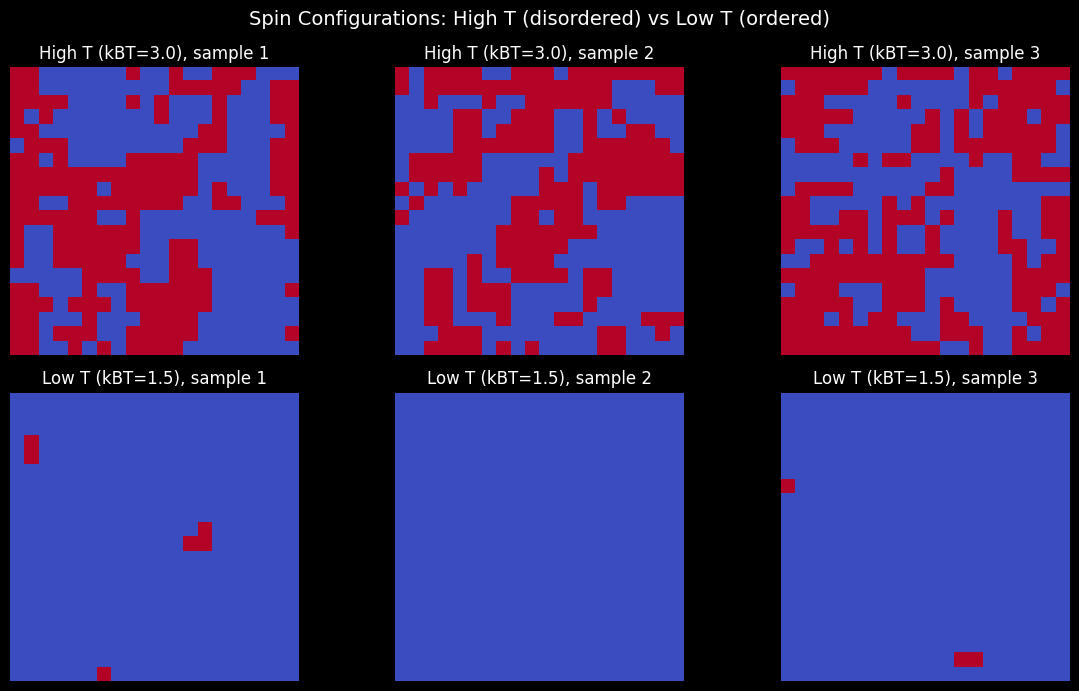

High T — sample |M|/N values: ['0.065', '0.090', '0.080', '0.025', '0.030']
Low  T — sample |M|/N values: ['0.970', '1.000', '0.985', '1.000', '0.990']


In [ ]:
rng = np.random.default_rng(3)
L_test = 20

# High temperature: kBT = 3.0  (should be disordered, random looking)
absM_h, M2_h, M4_h, E_h, configs_high = ising_mc(
    L_test, kBT=3.0, n_eq=200, n_sample=5, sample_interval=50,
    rng=rng, return_configs=True)

# Low temperature: kBT = 1.5  (should be ordered, mostly one colour)
absM_l, M2_l, M4_l, E_l, configs_low = ising_mc(
    L_test, kBT=1.5, n_eq=200, n_sample=5, sample_interval=50,
    rng=rng, return_configs=True)

# Plot 3 sample configs from each
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for col in range(3):
    axes[0, col].imshow(configs_high[col], vmin=-1, vmax=1)
    axes[0, col].set_title(f'High T (kBT=3.0), sample {col+1}')
    axes[0, col].axis('off')
    
    axes[1, col].imshow(configs_low[col],vmin=-1, vmax=1)
    axes[1, col].set_title(f'Low T (kBT=1.5), sample {col+1}')
    axes[1, col].axis('off')

plt.suptitle('Spins: High T (disordered) vs Low T (ordered)')
plt.tight_layout()
plt.show()


Yes The high T clearly Looks way more Chaotic. 

### 2. Full Data Generation

In [ ]:
import os

# Chat GPT suggested this OS module to help me with File analysis, it makes it more better
temperatures = [1.5, 2.0, 2.1, 2.2, 2.25, 2.26, 2.27, 2.28, 2.29, 2.3, 2.5, 3.0]
L_values = [10, 15, 20, 25]

n_eq = 200
sample_interval = 50
n_sample = 300

data_dir = 'ising_data'
os.makedirs(data_dir, exist_ok=True)



# Dictionary for mutablility
results = {}

rng = np.random.default_rng(1)

total_runs = len(L_values) * len(temperatures)
run = 0
for L in L_values:
    for kBT in temperatures:
        run += 1
        fname = os.path.join(data_dir, f'ising_L{L}_kBT{kBT:.2f}.dat')
        absM, M2, M4, E, _ = ising_mc(
            L, kBT, n_eq=n_eq, n_sample=n_sample,
            sample_interval=sample_interval, rng=rng, save_file=fname)
        results[(L, kBT)] = (absM, M2, M4, E)
        print(f'[{run}/{total_runs}]  L={L:2d}  kBT={kBT:.2f}  done  '
              f'<|M|>/N={np.mean(absM)/L**2:.3f}  <E>/N={np.mean(E)/L**2:.3f}')


[1/48]  L=10  kBT=1.50  done  <|M|>/N=0.986  <E>/N=-1.947
[2/48]  L=10  kBT=2.00  done  <|M|>/N=0.917  <E>/N=-1.759
[3/48]  L=10  kBT=2.10  done  <|M|>/N=0.871  <E>/N=-1.670
[4/48]  L=10  kBT=2.20  done  <|M|>/N=0.801  <E>/N=-1.537
[5/48]  L=10  kBT=2.25  done  <|M|>/N=0.775  <E>/N=-1.506
[6/48]  L=10  kBT=2.26  done  <|M|>/N=0.754  <E>/N=-1.465
[7/48]  L=10  kBT=2.27  done  <|M|>/N=0.751  <E>/N=-1.481
[8/48]  L=10  kBT=2.28  done  <|M|>/N=0.731  <E>/N=-1.447
[9/48]  L=10  kBT=2.29  done  <|M|>/N=0.743  <E>/N=-1.462
[10/48]  L=10  kBT=2.30  done  <|M|>/N=0.711  <E>/N=-1.416
[11/48]  L=10  kBT=2.50  done  <|M|>/N=0.547  <E>/N=-1.187
[12/48]  L=10  kBT=3.00  done  <|M|>/N=0.272  <E>/N=-0.812
[13/48]  L=15  kBT=1.50  done  <|M|>/N=0.986  <E>/N=-1.947
[14/48]  L=15  kBT=2.00  done  <|M|>/N=0.911  <E>/N=-1.746
[15/48]  L=15  kBT=2.10  done  <|M|>/N=0.876  <E>/N=-1.666
[16/48]  L=15  kBT=2.20  done  <|M|>/N=0.799  <E>/N=-1.557
[17/48]  L=15  kBT=2.25  done  <|M|>/N=0.743  <E>/N=-1.480
[18/48

## Task 4: 


In [ ]:
### 1. Ensemble Averages
# Organize ensemble averages into a structured dictionary
# 
avg = {}
for (L, kBT), (absM, M2, M4, E) in results.items():
    avg[(L, kBT)] = {
        'absM': np.mean(absM),
        'M2': np.mean(M2),
        'M4':np.mean(M4),
        'E':  np.mean(E),
        'E2': np.mean(E**2),
    }


### 2. Mean Absolute 

In [ ]:
plt.figure(figsize=(8, 5))
for L in L_values:
    Ts = []; mag = []
    for kBT in temperatures:
        N = L**2
        Ts.append(kBT)
        mag.append(avg[(L, kBT)]['absM'] / N)
    plt.plot(Ts, mag, 'o-', label=f'L={L}')

plt.axvline(2.27, color='gray', ls='--', lw=0.8, label=r'$k_BT_c \approx 2.27$')
plt.xlabel(r'$k_B T$')
plt.ylabel(r'$\langle |M| \rangle / N$')
plt.title('Average Absolute Magnetization per Spin')
plt.legend()
plt.show()

### 3. Analysis
At low temperature Below Curies Temp, the value is close to 1, so thats our ordered ferromagnetic area. 
As the temperature increases toward $k_BT_c \approx 2.27$, the magnetization goes down. 
On our finite lattices the transition is smoothed out like the gudie image shows.


In [ ]:
# 4. Specific Heat per Spin $C_V / (Nk_B)$ vs $T$
plt.figure(figsize=(8, 5))
for L in L_values:
    N = L**2
    Ts = []; cv = []
    for kBT in temperatures:
        a = avg[(L, kBT)]
        Cv_NkB = (1.0 / N) * (1.0 / kBT**2) * (a['E2'] - a['E']**2)
        Ts.append(kBT)
        cv.append(Cv_NkB)
    plt.plot(Ts, cv, 'o-', label=f'L={L}')

plt.axvline(2.27, color='gray', ls='--', lw=0.8, label=r'$k_BT_c \approx 2.27$')
plt.xlabel(r'$k_B T$')
plt.ylabel(r'$C_V / (Nk_B)$')
plt.title('Specific Heat per Spin')
plt.legend()
plt.show()

### 5. Analysis 
The specific heat shows has a peak. 
This is porbably the max  energy fluctuations

As $L$ increases:
he peak **grows taller** 
The peak **sharpens** and its position shifts slightly toward the exact $T_c$.


### 6. Magnetic Susceptibility per Spin $\chi_M / N$ vs $T$

In [ ]:
plt.figure(figsize=(8, 5))
for L in L_values:
    N = L**2
    Ts = []; chi = []
    for kBT in temperatures:
        a = avg[(L, kBT)]
        chi_N = (1.0 / N) * (1.0 / kBT) * (a['M2'] - a['absM']**2)
        Ts.append(kBT)
        chi.append(chi_N)
    plt.plot(Ts, chi, 'o-', label=f'L={L}')

plt.axvline(2.27, color='gray', ls='--', lw=0.8, label=r'$k_BT_c \approx 2.27$')
plt.xlabel(r'$k_B T$')
plt.ylabel(r'$\chi_M / N$')
plt.title('Magnetic Susceptibility per Spin')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7. Binder Cumulant $g(L, T)$

In [ ]:
plt.figure(figsize=(8, 5))
for L in L_values:
    Ts = []; binder = []
    for kBT in temperatures:
        a = avg[(L, kBT)]
        g = 1.5 * (1.0 - (1.0/3.0) * a['M4'] / a['M2']**2)
        Ts.append(kBT)
        binder.append(g)
    plt.plot(Ts, binder, 'o-', label=f'L={L}')

plt.axvline(2.27, color='gray', ls='--', lw=0.8, label=r'$k_BT_c \approx 2.27$')
plt.xlabel(r'$k_B T$')
plt.ylabel(r'$g(L, T)$')
plt.title('Binder Cumulant')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Task 5: Wrap Up

### 1. Feedback on Wording
I think, this time I would have liked more help and ideas on how to code this, more tips and guidance. 

### 2. Other Comments
This Gudie has to be the most Challenging for me, especially in terms of the Coding. 


Took me way too long to do, so Not gonna do the extras. 